model training

In [1]:
import pandas as pd
import os
import numpy as np

cancerous = ['BCC','MEL','SCC']
not_cancerous = ['ACK', 'NEV', 'SEK']

In [6]:
features_df = pd.read_csv('../data/features.csv')
features_df.head()
features_df.shape
features_df.isna().any(axis=1).sum()
features_df.isna().sum()

img_id                  0
asymmetry               1
compactness             0
convexity               0
Ls_value               17
as_value               17
bs_value               17
mean_angle_h           17
s_value                17
v_value                17
r_value                17
g_value                17
b_value                17
Ls_var                 17
as_var                 17
bs_var                 17
h_var                  17
s_var                  17
v_var                  17
r_var                  17
g_var                  17
b_var                  17
hsv_var_mean           17
rgb_var_mean           17
hsv_var_mag            17
rgb_var_mag            17
circular_max_min_h     17
diameter                0
fitz                  262
lacunarity              1
contrast                0
cancerous               0
dtype: int64

In [2]:
df = pd.read_csv('../data/metadata.csv')
df.head()





,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [3]:
mask_dir = "../data/masks"

necessary_df = df[
    df['img_id'].apply(lambda x: os.path.exists(f"{mask_dir}/{x.removesuffix(".png")}_mask.png"))][['img_id', 'diagnostic']].copy()
necessary_df['cancerous'] = necessary_df['diagnostic'].isin(cancerous)

df_sample = necessary_df.sample(n=200, random_state=42)
df_sample.head()


,img_id,diagnostic,cancerous
2017,PAT_537_1014_452.png,SCC,True
382,PAT_770_1451_136.png,SCC,True
1775,PAT_1247_852_178.png,ACK,False
310,PAT_270_1382_561.png,SEK,False
200,PAT_1298_1051_831.png,NEV,False


In [4]:
print("CWD:", os.getcwd())
print("Mask dir exists:", os.path.exists("../data/masks"))
print(os.listdir(mask_dir)[:10])

CWD: /Users/manasaliveliicloud.com/2026-PDS-Tigers/src
Mask dir exists: True
['PAT_1546_1872_824_mask.png', 'PAT_851_4520_743_mask.png', 'PAT_1184_676_904_mask.png', 'PAT_286_1458_381_mask.png', 'PAT_355_732_625_mask.png', 'PAT_1746_3284_798_mask.png', 'PAT_2034_4266_880_mask.png', 'PAT_860_1641_440_mask.png', 'PAT_313_669_935_mask.png', 'PAT_53_82_657_mask.png']


In [5]:
from asymmetry import extract_asymmetry  
from border import border
from color import color_features_extraction
from diameter import diameter
from evolution import evolution_score_row
from fitzpatrick import fitzpatrick
from Contrast_feature import contrast

In [8]:
import numpy as np

def safe_color_features_extraction(img_id):
    try:
        return color_features_extraction(img_id)
    except ValueError:  # catches the "more dimensions than allowed" error
        return np.nan

# Apply the safe version
df_sample['color'] = df_sample['img_id'].apply(safe_color_features_extraction)



np.int64(7)

In [9]:
df_sample['assymetry'] = df_sample['img_id'].apply(extract_asymmetry)


In [10]:
df_sample['border'] = df_sample['img_id'].apply(border)

In [11]:
df_sample.head()

,img_id,diagnostic,cancerous,fitz,color,assymetry,border
2017,PAT_537_1014_452.png,SCC,True,2.0,"[61.65154, -1.953455, 1.0080574, 2.4326806, 0....",0.087037,"[0.0013159564272671378, 0.47775545939487923]"
382,PAT_770_1451_136.png,SCC,True,5.0,"[25.003975, 13.170661, 3.6690717, -0.23018274,...",0.808419,"[0.008084333237942172, 0.2299716144924801]"
1775,PAT_1247_852_178.png,ACK,False,NaN,"[48.810062, 9.512719, -2.2186391, -0.5015774, ...",0.176000,"[0.0030103754396765187, 0.7100731898356365]"
310,PAT_270_1382_561.png,SEK,False,1.0,"[21.578413, 1.7848113, -0.72495985, -1.6947039...",0.360835,"[0.016464739695619533, 0.47371669103480923]"
200,PAT_1298_1051_831.png,NEV,False,NaN,"[40.03384, 28.306906, 24.724905, 0.2201642, 0....",0.120743,"[0.007959531648638956, 0.39902173756671605]"


In [12]:
df_sample = df_sample.dropna()

In [23]:
color_df = pd.DataFrame(df_sample['color'].tolist(), columns=['Ls_value', 'as_value', 'bs_value', 'mean_angle_h', 's_value', 'v_value', 'r_value', 'g_value', 'b_value','Ls_var', 'as_var', 'bs_var', 'h_var', 's_var', 'v_var', 'r_var', 'g_var', 'b_var', 'hsv_var_mean', 'rgb_var_mean', 'hsv_var_mag', 'rgb_var_mag', 'circular_max_min_h'])
color_df['cancerous'] = df_sample['cancerous']
color_df

,Ls_value,as_value,bs_value,mean_angle_h,s_value,v_value,r_value,g_value,b_value,Ls_var,...,v_var,r_var,g_var,b_var,hsv_var_mean,rgb_var_mean,hsv_var_mag,rgb_var_mag,circular_max_min_h,cancerous
0,61.651539,-1.953455,1.008057,2.432681,0.072909,0.598038,0.572215,0.588813,0.578073,56.280537,...,0.005886,0.003119,0.006636,0.009778,0.176144,0.006511,0.521247,0.012222,0.429061,NaN
1,25.003975,13.170661,3.669072,-0.230183,0.389344,0.315002,0.312271,0.205711,0.218500,51.935589,...,0.001420,0.001205,0.006342,0.006798,0.013104,0.004782,0.030224,0.009375,0.042998,NaN
2,21.578413,1.784811,-0.724960,-1.694704,0.142633,0.227757,0.213765,0.201702,0.208540,57.100098,...,0.005529,0.006954,0.003848,0.002593,0.119769,0.004465,0.351720,0.008360,0.402289,NaN
3,52.113834,13.103271,7.848825,0.103502,0.267576,0.592659,0.592572,0.455374,0.437496,8.930864,...,0.001695,0.001696,0.000797,0.000384,0.002843,0.000959,0.005673,0.001913,0.039311,NaN
4,61.033409,11.166314,-1.684756,-0.433545,0.153053,0.650497,0.650039,0.552420,0.591025,20.292915,...,0.001735,0.001745,0.002318,0.002128,0.000714,0.002064,0.001780,0.003598,0.001529,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,44.588451,18.049700,15.937718,0.235233,0.442072,0.554984,0.554904,0.368135,0.316010,68.941811,...,0.003179,0.003167,0.009093,0.009952,0.006265,0.007404,0.015466,0.013848,0.011422,NaN
134,73.717880,7.277040,7.555036,0.286602,0.166962,0.783823,0.783533,0.691561,0.658678,48.862869,...,0.001130,0.001114,0.007917,0.007056,0.010886,0.005362,0.026471,0.010663,0.110371,NaN
135,43.879086,18.124199,2.566230,-0.407588,0.347469,0.529804,0.517932,0.364505,0.398947,166.942276,...,0.008568,0.004816,0.022367,0.032037,0.072724,0.019740,0.183450,0.039368,0.313483,NaN
136,59.708324,8.949444,4.532439,0.095947,0.181500,0.637235,0.636835,0.542567,0.535510,24.760830,...,0.000343,0.000330,0.004068,0.002281,0.004686,0.002226,0.010201,0.004676,0.042932,NaN


In [24]:
border_df = pd.DataFrame(df_sample['border'].tolist(), columns=['compactness', 'convexity'])
border_df['cancerous'] = df_sample['cancerous']
border_df

,compactness,convexity,cancerous
0,0.001316,0.477755,NaN
1,0.008084,0.229972,NaN
2,0.016465,0.473717,NaN
3,0.003416,0.688343,NaN
4,0.001274,0.690274,NaN
...,...,...,...
133,0.019924,0.748621,NaN
134,0.008582,0.291835,NaN
135,0.000697,0.346537,NaN
136,0.002393,0.468548,NaN


In [15]:
print(list(df_sample.columns))

['img_id', 'diagnostic', 'cancerous', 'fitz', 'color', 'assymetry', 'border']


In [16]:
df_sample['contrast'] = df_sample['img_id'].apply(contrast)

/var/folders/ld/58y_dbxx6xxg579fnlpz8kr00000gn/T/ipykernel_24251/77429887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['contrast'] = df_sample['img_id'].apply(contrast)


In [17]:
df_sample['diameter'] = df_sample['img_id'].apply(diameter)

/var/folders/ld/58y_dbxx6xxg579fnlpz8kr00000gn/T/ipykernel_24251/247435203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['diameter'] = df_sample['img_id'].apply(diameter)


In [18]:
df_sample['evolution'] = df_sample.apply(evolution_score_row, axis=1)

/var/folders/ld/58y_dbxx6xxg579fnlpz8kr00000gn/T/ipykernel_24251/1801414714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['evolution'] = df_sample.apply(evolution_score_row, axis=1)


In [19]:
df_sample['fitz'] = df_sample['img_id'].apply(fitzpatrick)

/var/folders/ld/58y_dbxx6xxg579fnlpz8kr00000gn/T/ipykernel_24251/2968134969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['fitz'] = df_sample['img_id'].apply(fitzpatrick)


In [53]:
color_df = pd.DataFrame(
    df_sample['color'].tolist(),
    columns=['Ls_value', 'as_value', 'bs_value', 'mean_angle_h',
             's_value', 'v_value', 'r_value', 'g_value', 'b_value',
             'Ls_var', 'as_var', 'bs_var', 'h_var', 's_var', 'v_var',
             'r_var', 'g_var', 'b_var', 'hsv_var_mean', 'rgb_var_mean',
             'hsv_var_mag', 'rgb_var_mag', 'circular_max_min_h']
)


In [50]:
border_df = pd.DataFrame(
    df_sample['border'].tolist(),
    columns=['compactness', 'convexity']
)

In [51]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
x = pd.concat([
    color_df.reset_index(drop=True),
    df_sample[['assymetry', 'contrast', 'diameter', 'fitz']].reset_index(drop=True),
    border_df.reset_index(drop=True)
], axis=1)

y = df_sample['cancerous'].reset_index(drop=True)

x = x.dropna()
y = y.loc[x.index]



dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0, test_size=0.2)









#### standardisation

In [54]:
# 2. Standardize the data
scaler = StandardScaler()

# Fit and transform the development data
dev_x_scaled = scaler.fit_transform(dev_x)

# ONLY transform the test data (using dev_x's mean and std)
test_x_scaled = scaler.transform(test_x)



In [ ]:
knn = KNeighborsClassifier()

# Define the k values to test
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19]
}

# 4. Run Grid Search with 5-fold CV and AUC scoring
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


grid_search.fit(dev_x_scaled, dev_y)

# --- RESULTS ---

print(f"Best k value: {grid_search.best_params_['n_neighbors']}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# 5. Final check on the Test Set
best_model = grid_search.best_estimator_
test_auc = best_model.score(test_x_scaled, test_y)

print(f"Final Test AUC: {test_auc:.4f}")

Best k value: 19
Best CV AUC: 0.6732
Final Test AUC: 0.7143


Exception ignored in: <function ResourceTracker.__del__ at 0x107a55d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1049cdd00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1078d1d00>
Traceback (most recent call last

### Plotting based on features

--- Top Linear Correlations ---
target                1.000000
v_value               0.286373
r_var                 0.262923
g_var                 0.260896
v_var                 0.260785
compactness           0.220382
hsv_var_mag           0.199228
rgb_var_mag           0.191599
rgb_var_mean          0.189350
hsv_var_mean          0.151483
s_var                 0.121412
r_value               0.103693
s_value               0.103301
circular_max_min_h    0.035951
b_var                 0.022933
h_var                -0.029281
g_value              -0.076976
convexity            -0.101736
b_value              -0.151174
h_sin                -0.342640
assymetry            -0.609479
Name: target, dtype: float64

--- Mutual Information Scores ---
assymetry             0.105061
h_sin                 0.085781
r_var                 0.067063
compactness           0.062080
v_var                 0.058464
b_var                 0.038265
b_value               0.033046
hsv_var_mean          0.025529
h_var

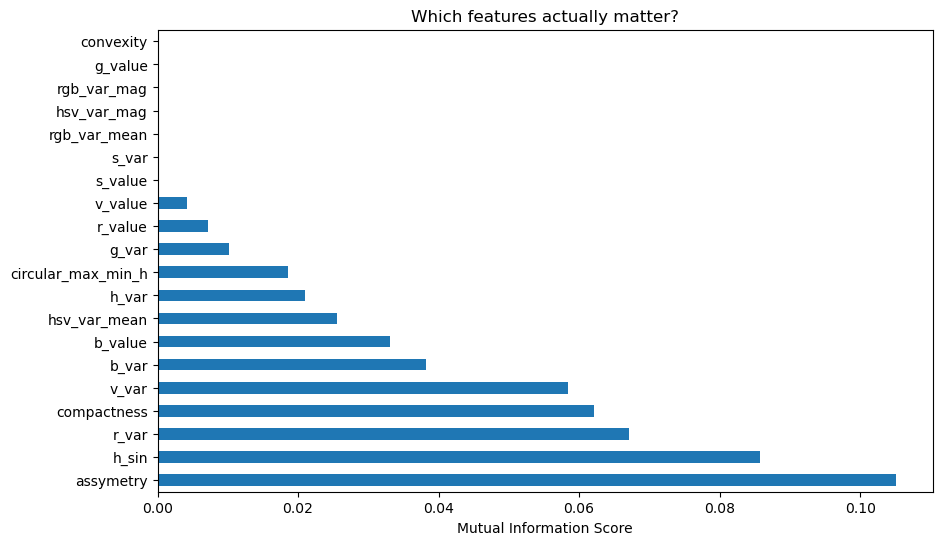

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# 1. Simple Correlation (Linear)
# We look at how much each column relates to 'y'
# Assuming x is a DataFrame and y is a Series
df = x.copy()
df['target'] = y
correlations = df.corr()['target'].sort_values(ascending=False)

print("--- Top Linear Correlations ---")
print(correlations)

# 2. Mutual Information (Non-Linear)
# This is GREAT for KNN because it captures any kind of relationship
# 0 = no relationship, higher = stronger relationship
mi_scores = mutual_info_classif(x, y, random_state=0)
mi_series = pd.Series(mi_scores, name="MI Scores", index=x.columns)
mi_series = mi_series.sort_values(ascending=False)

print("\n--- Mutual Information Scores ---")
print(mi_series)

# 3. Quick Visualization
plt.figure(figsize=(10, 6))
mi_series.plot(kind='barh')
plt.title("Which features actually matter?")
plt.xlabel("Mutual Information Score")
plt.show()

In [ ]:
important_features = ['assymetry', 'h_sin', 'r_var', 'compactness','v_var', 'b_var', 'h_var']
x_filtered = x[important_features]

# 2. Re-split with the filtered features
dev_x, test_x, dev_y, test_y = train_test_split(
    x_filtered, y, stratify=y, random_state=0, test_size=0.2
)

# 3. Scale ONLY these 3 features
scaler = StandardScaler()
dev_x_scaled = scaler.fit_transform(dev_x)
test_x_scaled = scaler.transform(test_x)

# 4. Re-run your Grid Search (using the code from before)
grid_search.fit(dev_x_scaled, dev_y)

print(f"New Best CV AUC: {grid_search.best_score_:.4f}")

New Best CV AUC: 0.7215


### Plots

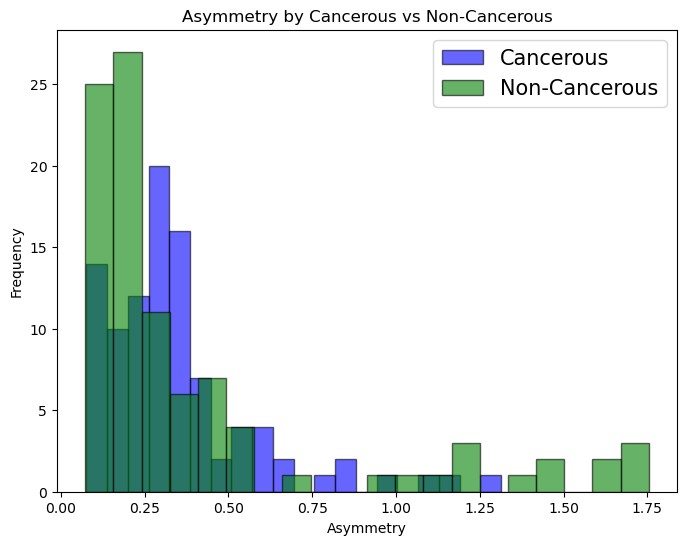

In [ ]:
import matplotlib.pyplot as plt

#Asymmetry:
cancerous_vals = df_sample[df_sample['cancerous'] == True]['assymetry']
not_cancerous_vals = df_sample[df_sample['cancerous'] == False]['assymetry']

plt.figure(figsize=(8, 6))
plt.hist(cancerous_vals, bins = 20, alpha = 0.6, label ='Cancerous', color = "blue", edgecolor = 'black')
plt.hist(not_cancerous_vals, bins = 20, alpha = 0.6, label = 'Non-Cancerous', color = "green", edgecolor = 'black')
plt.title('Asymmetry by Cancerous vs Non-Cancerous')
plt.xlabel('Asymmetry')
plt.ylabel('Frequency')
plt.legend(fontsize = 15)
plt.show()

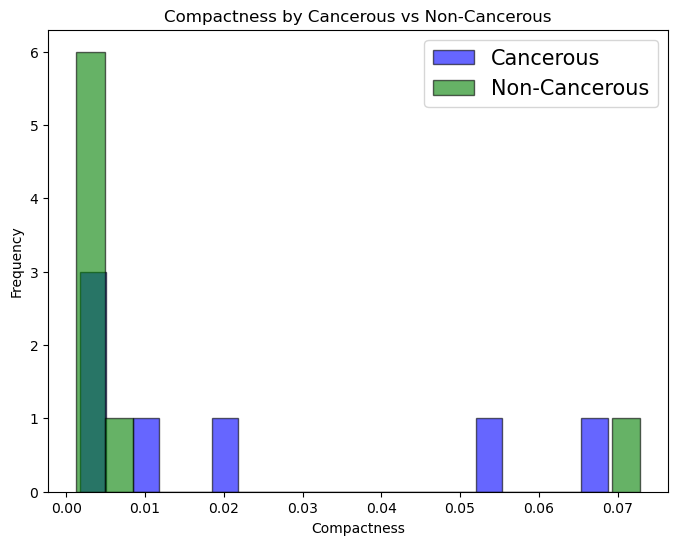

In [ ]:
#Border - compactness:

cancerous_vals_comp = border_df[border_df['cancerous'] == True]['compactness']
not_cancerous_vals_comp = border_df[border_df['cancerous'] == False]['compactness']

plt.figure(figsize=(8, 6))
plt.hist(cancerous_vals_comp, bins = 20, alpha = 0.6, label ='Cancerous', color = "blue", edgecolor = 'black')
plt.hist(not_cancerous_vals_comp, bins = 20, alpha = 0.6, label = 'Non-Cancerous', color = "green", edgecolor = 'black')
plt.title('Compactness by Cancerous vs Non-Cancerous')
plt.xlabel('Compactness')
plt.ylabel('Frequency')
plt.legend(fontsize = 15)
plt.show()

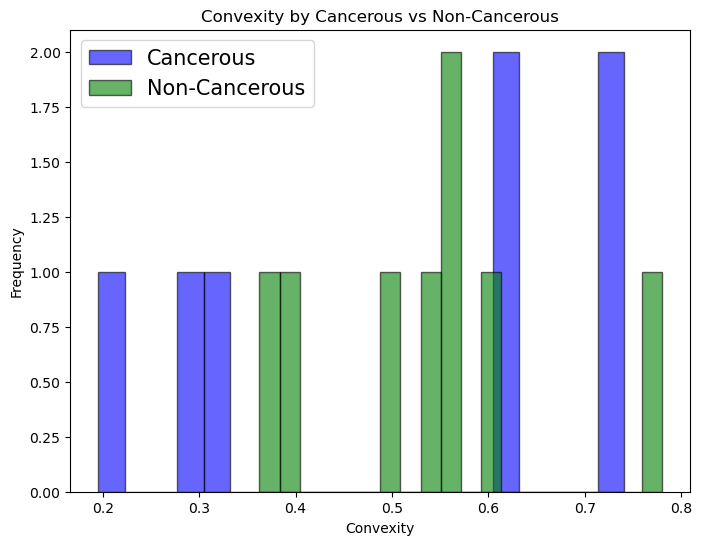

In [ ]:
#Border - convexity:
cancerous_vals_conv = border_df[border_df['cancerous'] == True]['convexity']
not_cancerous_vals_conv = border_df[border_df['cancerous'] == False]['convexity']

plt.figure(figsize=(8, 6))
plt.hist(cancerous_vals_conv, bins = 20, alpha = 0.6, label ='Cancerous', color = "blue", edgecolor = 'black')
plt.hist(not_cancerous_vals_conv, bins = 20, alpha = 0.6, label = 'Non-Cancerous', color = "green", edgecolor = 'black')
plt.title('Convexity by Cancerous vs Non-Cancerous')
plt.xlabel('Convexity')
plt.ylabel('Frequency')
plt.legend(fontsize = 15)
plt.show()

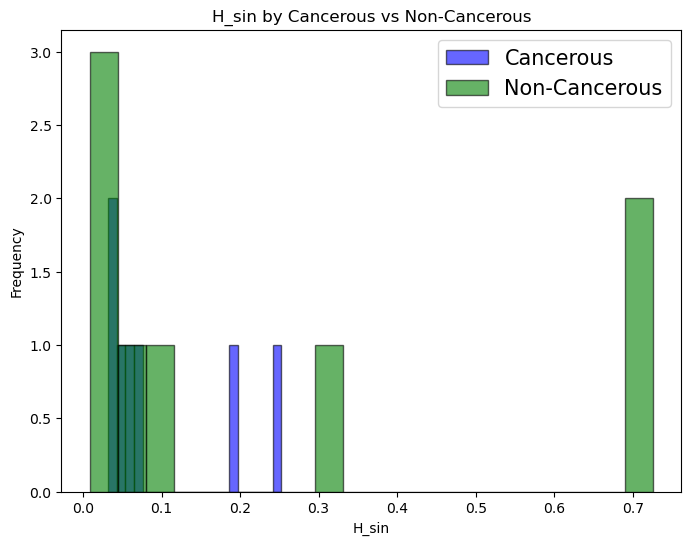

In [ ]:
#Color - h_sin:
cancerous_vals_h_sin = color_df[color_df['cancerous'] == True]['h_sin']
not_cancerous_vals_h_sin = color_df[color_df['cancerous'] == False]['h_sin']

plt.figure(figsize=(8, 6))
plt.hist(cancerous_vals_h_sin, bins = 20, alpha = 0.6, label ='Cancerous', color = "blue", edgecolor = 'black')
plt.hist(not_cancerous_vals_h_sin, bins = 20, alpha = 0.6, label = 'Non-Cancerous', color = "green", edgecolor = 'black')
plt.title('H_sin by Cancerous vs Non-Cancerous')
plt.xlabel('H_sin')
plt.ylabel('Frequency')
plt.legend(fontsize = 15)
plt.show()